In [73]:
# load swap seqs + annotations from the precomputed npz (written by mcs_k562/scripts/swap_experiment.ipynb).
# strings only -> no torch/pandas needed in the flex (TF) env.
import sys, numpy as np
from pathlib import Path
sys.path.insert(0, "/grid/koo/home/pmantill/projects/AlphagenomeFT_modalities/"
                   "Alphagenome_mpra-datasets/Wong_lab_mouse-ap1/flex_interp/scripts")
import flex_model

Z = np.load(Path("data/swap_seqs.npz"))
names, wt = Z["names"], Z["wt"]
high, low = Z["high"].tolist(), Z["low"].tolist()
hi = set(high)

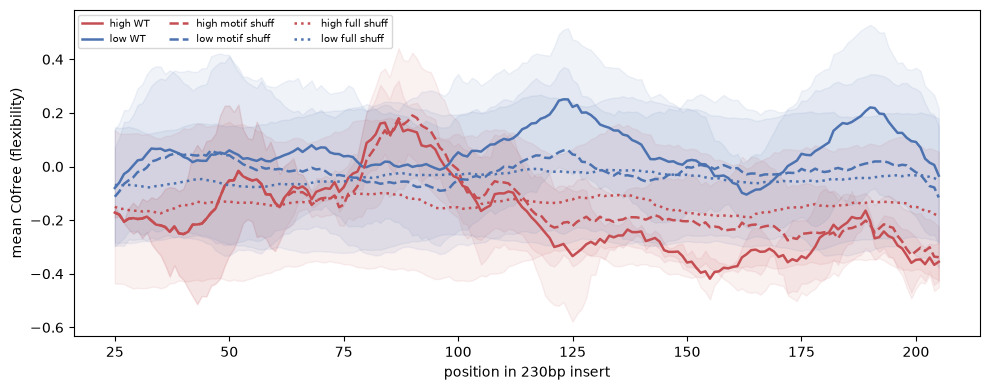

In [74]:
# summary flex: WT vs motif-shuff vs full-shuff, high (red) vs low (blue), mean +/- std, full 230bp insert.
# color = class, linestyle = condition. shuffles pool all reps of the class.
import matplotlib.pyplot as plt

mk_idx = Z["motifko_idx"]
prof = {
    ("WT", "high"): flex_model.profile_matrix([wt[i] for i in high]),
    ("WT", "low"):  flex_model.profile_matrix([wt[i] for i in low]),
    ("motif shuff", "high"): flex_model.profile_matrix([s for row, i in zip(Z["motifko"], mk_idx) if i in hi for s in row]),
    ("motif shuff", "low"):  flex_model.profile_matrix([s for row, i in zip(Z["motifko"], mk_idx) if i not in hi for s in row]),
    ("full shuff", "high"): flex_model.profile_matrix([s for row, i in zip(Z["fullshuf"], mk_idx) if i in hi for s in row]),
    ("full shuff", "low"):  flex_model.profile_matrix([s for row, i in zip(Z["fullshuf"], mk_idx) if i not in hi for s in row]),
}
win_center = np.arange(prof[("WT", "high")].shape[1]) + 50 // 2
color = {"high": "#c44e52", "low": "#4c72b0"}
style = {"WT": "-", "motif shuff": "--", "full shuff": ":"}

plt.figure(figsize=(10, 4))
for (cond, cls), p in prof.items():
    mu, sd = p.mean(0), p.std(0)
    plt.plot(win_center, mu, color=color[cls], ls=style[cond], lw=1.8, label=f"{cls} {cond}")
    plt.fill_between(win_center, mu - sd, mu + sd, color=color[cls], alpha=0.08)
plt.xlabel("position in 230bp insert"); plt.ylabel("mean C0free (flexibility)")
plt.legend(fontsize=7, ncol=3); plt.tight_layout()

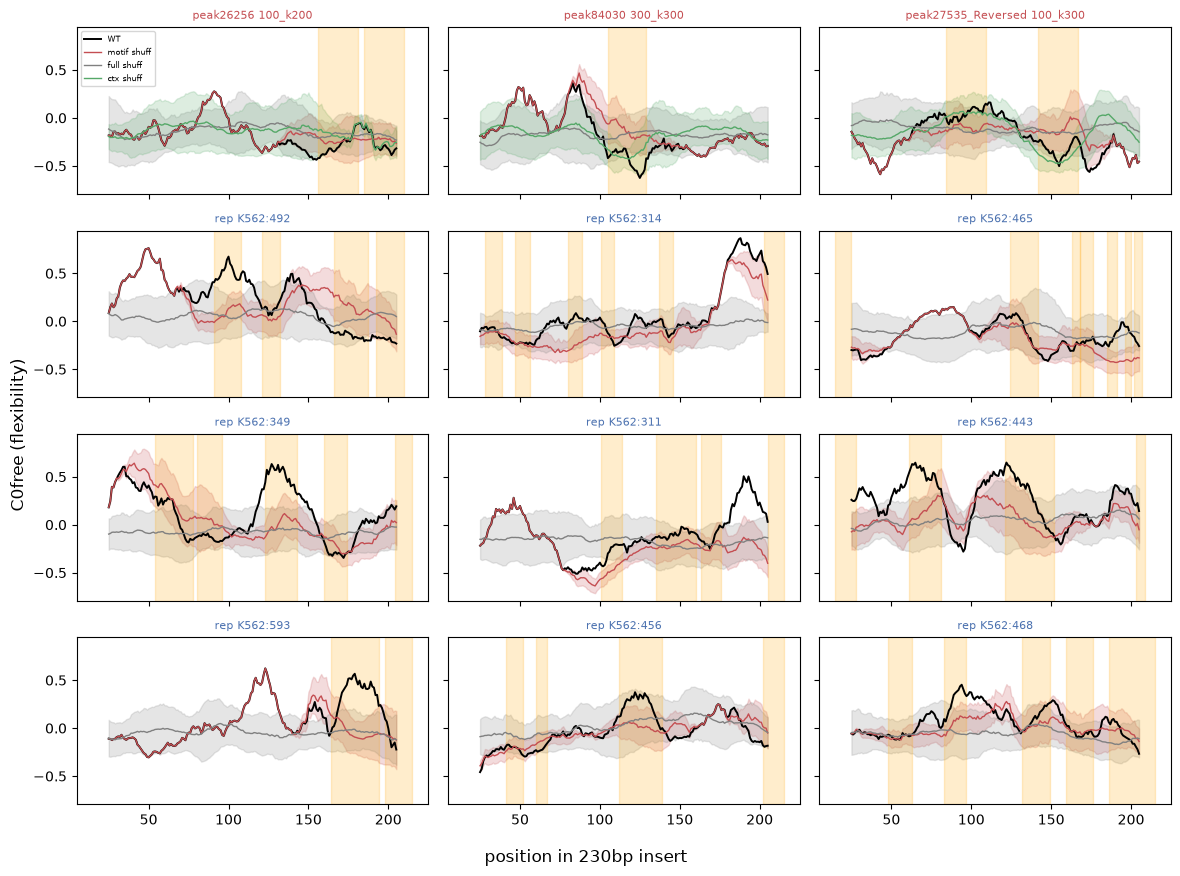

In [83]:
# per-seq flex: WT vs motif-shuff (motifs neutralized) vs full-shuff (whole insert dinuc-shuffled) vs
# ctx-shuff (motifs kept, context shuffled; high seqs only). shuffles = mean +/- std over reps (WT has no
# reps); annotated motif spans shaded. one panel per seq (red title = high, blue = low).
import matplotlib.pyplot as plt

order = Z["motifko_idx"].tolist()
prof_wt = flex_model.profile_matrix([wt[i] for i in order])                          # (n,181)
ms_mats = [flex_model.profile_matrix(list(row)) for row in Z["motifko"]]             # per seq (N_reps,181)
fs_mats = [flex_model.profile_matrix(list(row)) for row in Z["fullshuf"]]
cs_by_id = {int(idx): flex_model.profile_matrix(list(row)) for row, idx in zip(Z["ctxshuf"], Z["ctxshuf_idx"])}  # high only
win_center = np.arange(prof_wt.shape[1]) + 50 // 2

ncol = 3
nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.2 * nrow), sharex=True, sharey=True, squeeze=False)
for ax, i, pw, ms, fs in zip(axes.ravel(), order, prof_wt, ms_mats, fs_mats):
    ax.plot(win_center, pw, color="black", lw=1.4, label="WT")
    conds = [(ms, "#c44e52", "motif shuff"), (fs, "0.5", "full shuff")]
    if i in cs_by_id:
        conds.append((cs_by_id[i], "#55a868", "ctx shuff"))
    for mat, color, lab in conds:
        mu, sd = mat.mean(0), mat.std(0)
        ax.plot(win_center, mu, color=color, lw=1, label=lab)
        ax.fill_between(win_center, mu - sd, mu + sd, color=color, alpha=0.2)
    for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == i], Z["mspan_end"][Z["mspan_seq"] == i]):
        ax.axvspan(s, e, color="orange", alpha=0.2)
    ax.set_title(names[i], fontsize=8, color="#c44e52" if i in hi else "#4c72b0")
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
axes[0, 0].legend(fontsize=6)
fig.supxlabel("position in 230bp insert"); fig.supylabel("C0free (flexibility)")
fig.tight_layout()

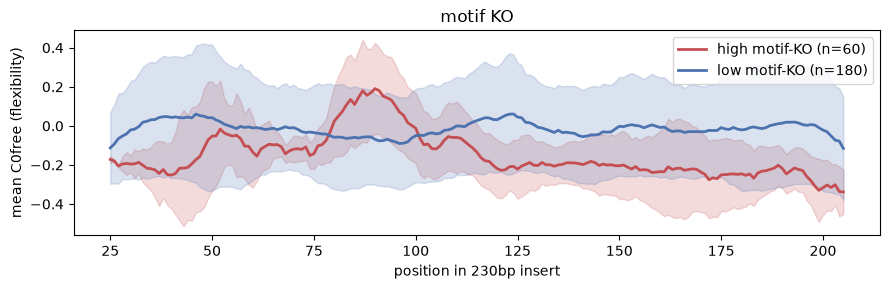

In [76]:
# motif-KO flex: own motifs neutralized (dinuc-shuffled at motif positions), context kept WT.
# same mean+/-std C0free profile, high vs low, over the full 230bp insert. seqs from swap_experiment.ipynb.
Z = np.load(Path("data/swap_seqs.npz"))
hi = set(Z["high"].tolist())
mk_high = [s for row, i in zip(Z["motifko"], Z["motifko_idx"]) if i in hi for s in row]
mk_low  = [s for row, i in zip(Z["motifko"], Z["motifko_idx"]) if i not in hi for s in row]

prof_mk_high = flex_model.profile_matrix(mk_high)
prof_mk_low  = flex_model.profile_matrix(mk_low)
win_center = np.arange(prof_mk_high.shape[1]) + 50 // 2

plt.figure(figsize=(9, 3))
for prof, color, lab in [(prof_mk_high, "#c44e52", "high"), (prof_mk_low, "#4c72b0", "low")]:
    mu, sd = prof.mean(0), prof.std(0)
    plt.plot(win_center, mu, color=color, lw=2, label=f"{lab} motif-KO (n={len(prof)})")
    plt.fill_between(win_center, mu - sd, mu + sd, color=color, alpha=0.2)
plt.xlabel("position in 230bp insert"); plt.ylabel("mean C0free (flexibility)")
plt.title("motif KO"); plt.legend(); plt.tight_layout()

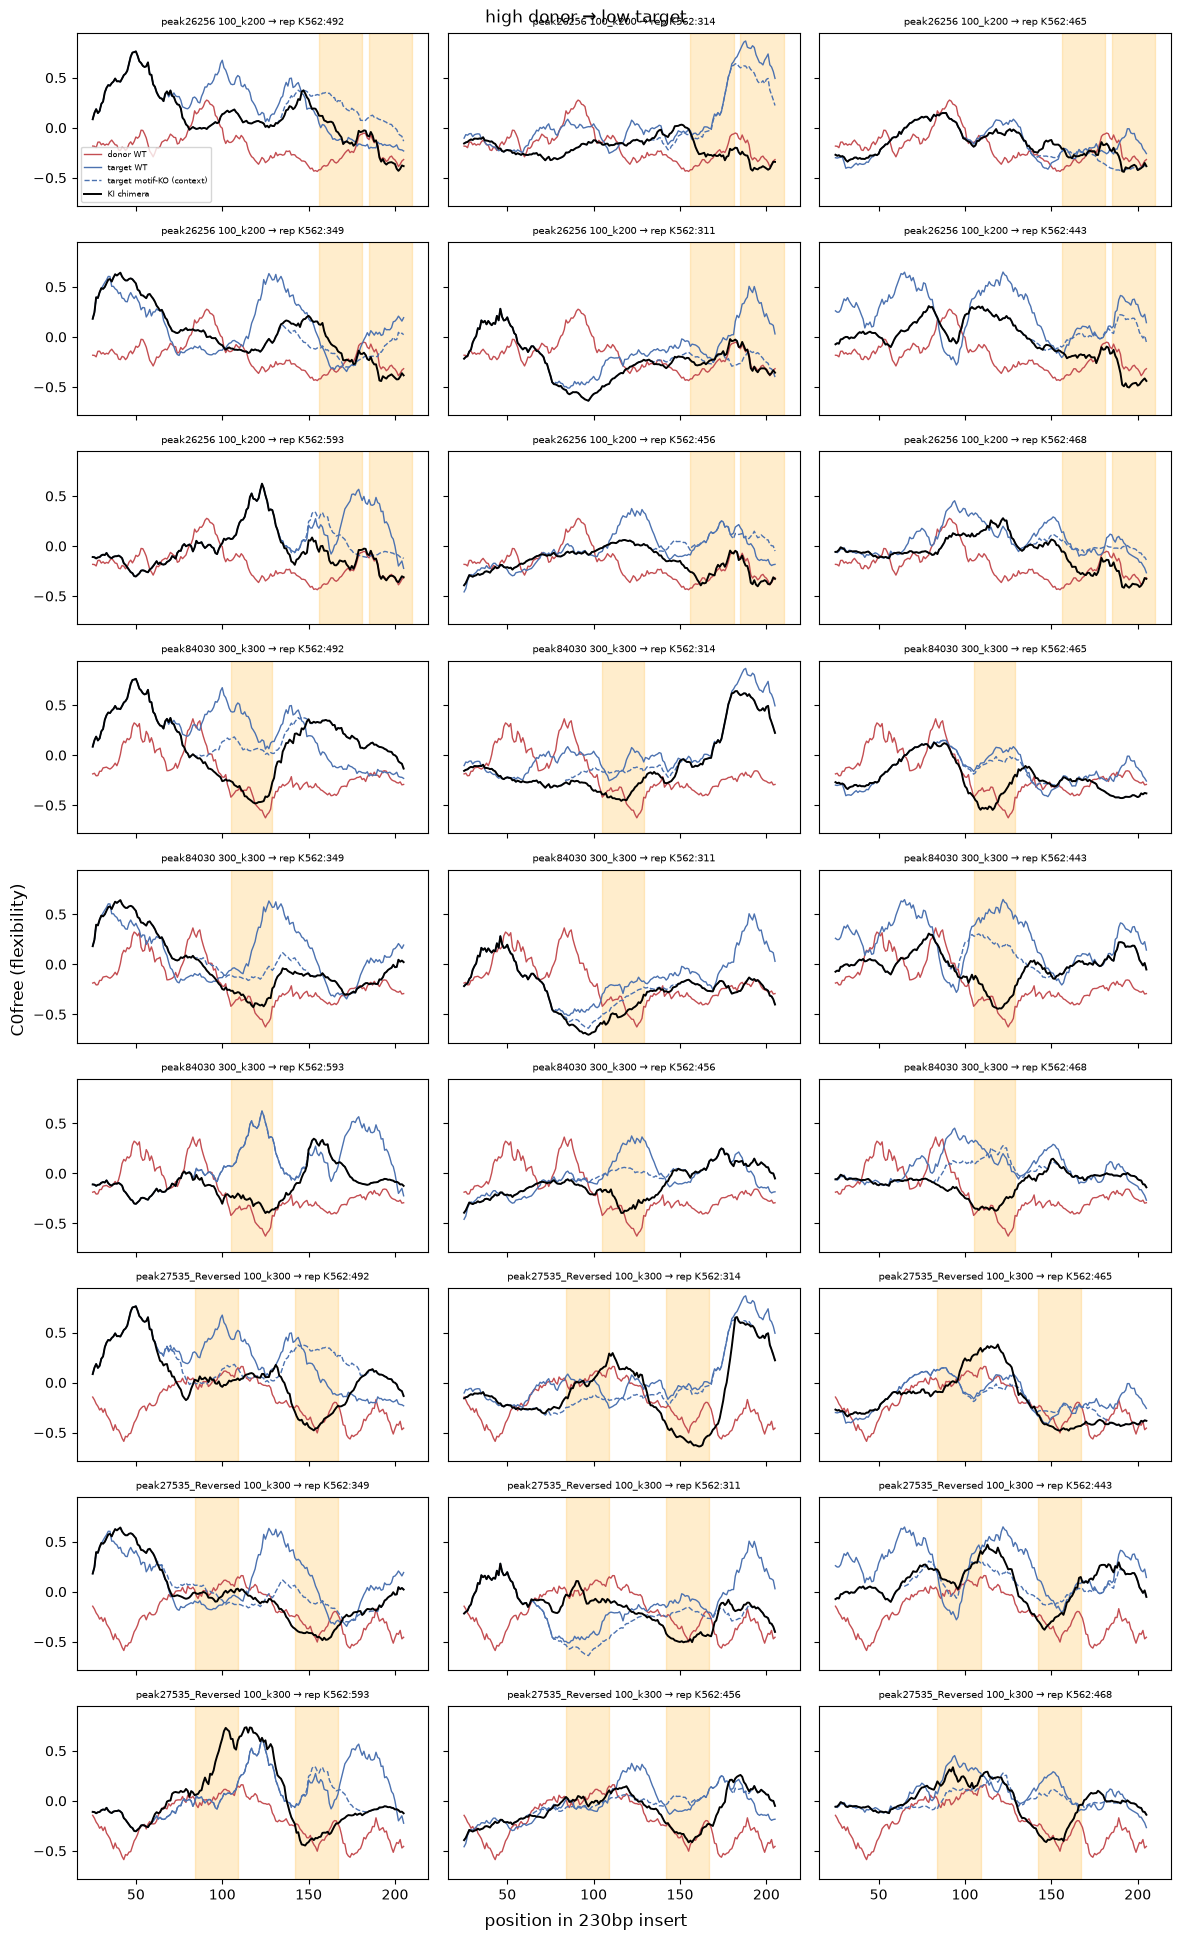

In [77]:
# per-chimera flex: donor WT / target WT / target motif-KO (the neutralized context) / KI chimera
# (reps averaged) in each panel. The KI chimera IS the target motif-KO with the donor motifs dropped in
# (shaded = injected donor-motif spans). one panel per (donor, target) pair. This cell: high donor -> low target.
prof_wt_all = flex_model.profile_matrix(list(wt))                                            # (13,181) by seq id
prof_ki = np.stack([flex_model.profile_matrix(list(row)).mean(0) for row in Z["chimera"]])   # (n_pairs,181)
prof_mko = {i: flex_model.profile_matrix(list(row)).mean(0)                                   # motif-KO (context) by seq id
            for row, i in zip(Z["motifko"], Z["motifko_idx"].tolist())}
don, tgt = Z["chimera_donor"], Z["chimera_target"]

def chimera_grid(mask, title):
    idx = np.where(mask)[0]
    ncol = 3
    nrow = int(np.ceil(len(idx) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.2 * nrow), sharex=True, sharey=True, squeeze=False)
    for ax, k in zip(axes.ravel(), idx):
        d, t = int(don[k]), int(tgt[k])
        ax.plot(win_center, prof_wt_all[d], color="#c44e52", lw=1, label="donor WT")
        ax.plot(win_center, prof_wt_all[t], color="#4c72b0", lw=1, label="target WT")
        ax.plot(win_center, prof_mko[t], color="#4c72b0", lw=1, ls="--", label="target motif-KO (context)")
        ax.plot(win_center, prof_ki[k], color="black", lw=1.4, label="KI chimera")
        for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == d], Z["mspan_end"][Z["mspan_seq"] == d]):
            ax.axvspan(s, e, color="orange", alpha=0.2)                                       # injected donor-motif spans
        ax.set_title(f"{names[d]} → {names[t]}", fontsize=7)
    for ax in axes.ravel()[len(idx):]:
        ax.axis("off")
    axes[0, 0].legend(fontsize=6)
    fig.suptitle(title); fig.supxlabel("position in 230bp insert"); fig.supylabel("C0free (flexibility)")
    fig.tight_layout()

chimera_grid(np.isin(don, high) & np.isin(tgt, low), "high donor → low target")

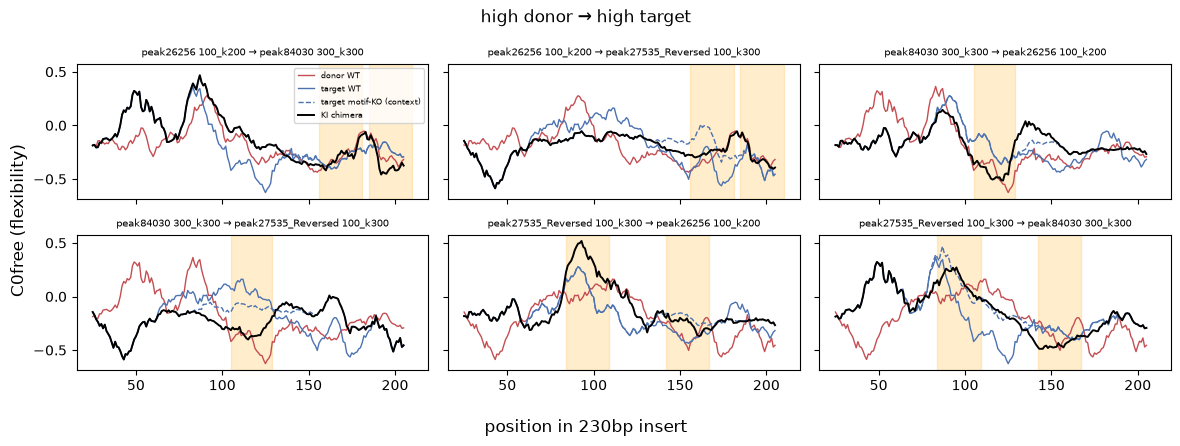

In [78]:
# chimeras: high donor -> high target
chimera_grid(np.isin(don, high) & np.isin(tgt, high), "high donor → high target")

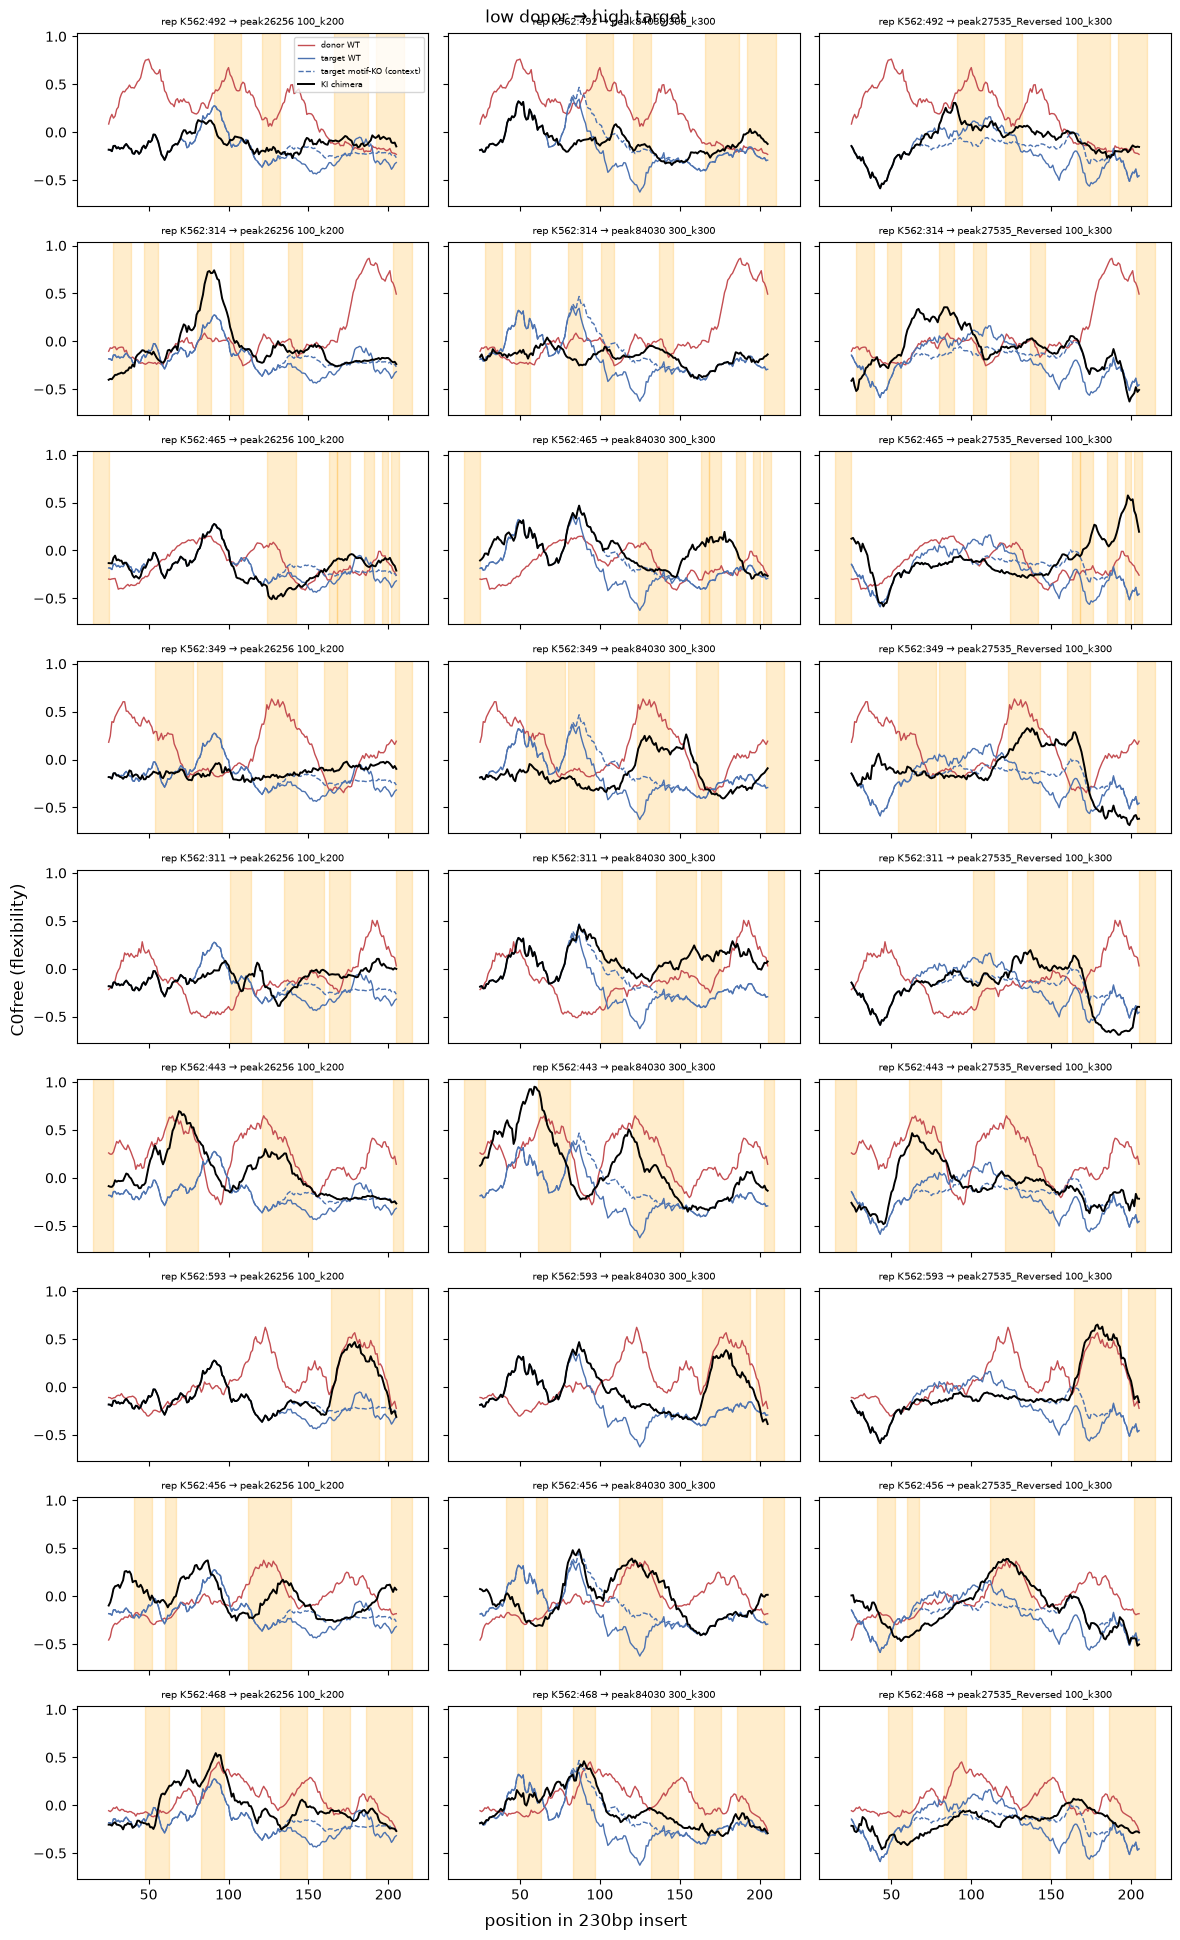

In [79]:
# chimeras: low donor -> high target
chimera_grid(np.isin(don, low) & np.isin(tgt, high), "low donor → high target")

loaded data/evo_traj.npz (27 pairs) — delete the file to recompute


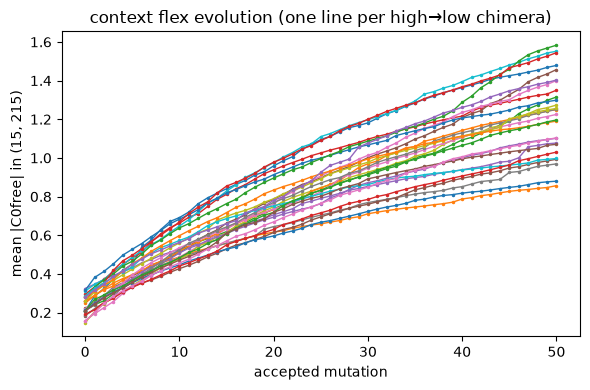

In [81]:
# flex-guided evolution of EACH high->low chimera's context (motif positions fixed): greedily mutate context
# bases to raise flex magnitude (mean |C0free|) over the variable region. Saves all trajectories for K562
# scoring in swap_experiment.ipynb. Skips if evo_traj.npz already exists (delete it to recompute).
# SLOW when it does run: subset via PAIRS (e.g. range(5)).
REGION = (15, 215)                    # variable region (insert minus 15bp adapters); mutate context + boost flex here
N_STEPS, N_TRY = 50, 200             # greedy steps; random single-base trials per step
EVO_PATH = Path("data/evo_traj.npz")

if EVO_PATH.exists():
    E = np.load(EVO_PATH); all_obj, all_pair = E["obj"], E["pair"]
    print(f"loaded {EVO_PATH} ({len(np.unique(all_pair))} pairs) — delete the file to recompute")
else:
    rng = np.random.default_rng(0)
    sels = np.where(np.isin(don, high) & np.isin(tgt, low))[0]
    PAIRS = range(len(sels))              # <- subset here to go faster
    region_win = (win_center >= REGION[0]) & (win_center < REGION[1])
    all_seq, all_obj, all_pair, pdon, ptgt = [], [], [], [], []
    for pi in PAIRS:
        sel = sels[pi]; d, t = int(don[sel]), int(tgt[sel])
        seq = np.array(list(Z["chimera"][sel][0]))
        motif_pos = {p for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == d], Z["mspan_end"][Z["mspan_seq"] == d]) for p in range(s, e)}
        mutable = [p for p in range(REGION[0], REGION[1]) if p not in motif_pos]
        tseq, tobj = ["".join(seq)], [np.abs(flex_model.profile("".join(seq))[region_win]).mean()]
        for _ in range(N_STEPS):
            pos, base = rng.choice(mutable, N_TRY), rng.choice(list("ACGT"), N_TRY)
            cands = []
            for p, b in zip(pos, base):
                c = seq.copy(); c[p] = b; cands.append("".join(c))
            obj = np.abs(flex_model.profile_matrix(cands)[:, region_win]).mean(1)
            k = int(obj.argmax())
            if obj[k] > tobj[-1]:
                seq = np.array(list(cands[k])); tseq.append(cands[k]); tobj.append(float(obj[k]))
        all_seq += tseq; all_obj += tobj; all_pair += [pi] * len(tseq); pdon.append(d); ptgt.append(t)
        print(f"pair {pi}: {names[d]} -> {names[t]}: flex {tobj[0]:.3f} -> {tobj[-1]:.3f} ({len(tseq)} steps)")
    all_obj, all_pair = np.array(all_obj), np.array(all_pair)
    np.savez(EVO_PATH, seqs=np.array(all_seq), obj=all_obj, pair=all_pair,
             donor=np.array(pdon), target=np.array(ptgt), region=np.array(REGION))

plt.figure(figsize=(6, 4))
for pi in np.unique(all_pair):
    plt.plot(all_obj[all_pair == pi], marker=".", ms=3, lw=1)
plt.xlabel("accepted mutation"); plt.ylabel(f"mean |C0free| in {REGION}")
plt.title("context flex evolution (one line per high→low chimera)"); plt.tight_layout()

peak26256 100_k200 ctx-shuffled: flex 0.271 -> 1.062 (51 steps)
peak84030 300_k300 ctx-shuffled: flex 0.228 -> 1.356 (51 steps)
peak27535_Reversed 100_k300 ctx-shuffled: flex 0.266 -> 1.113 (51 steps)


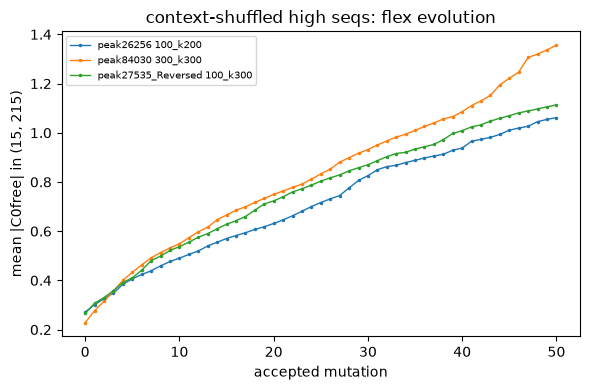

In [82]:
# SECOND evolution: start from each HIGH WT seq with its CONTEXT shuffled (motifs intact, context dinuc-shuffled).
# Can raising context flex alone rebuild activity once the native context is destroyed? Separate output file so
# the chimera trajectories above are untouched. Skips if evo_ctxshuf.npz exists (delete it to recompute).
REGION = (15, 215)                    # variable region; mutate context + boost flex here
N_STEPS, N_TRY = 50, 200
CS_PATH = Path("data/evo_ctxshuf.npz")

if CS_PATH.exists():
    E = np.load(CS_PATH); all_obj, all_pair, pidx = E["obj"], E["pair"], E["seq_idx"].tolist()
    print(f"loaded {CS_PATH} ({len(pidx)} seqs) — delete the file to recompute")
else:
    rng = np.random.default_rng(1)
    region_win = (win_center >= REGION[0]) & (win_center < REGION[1])

    def evolve(seq0, motif_pos):          # greedy: raise mean|C0free| in region, motif positions fixed
        seq = np.array(list(seq0))
        mutable = [p for p in range(REGION[0], REGION[1]) if p not in motif_pos]
        tseq, tobj = [seq0], [np.abs(flex_model.profile(seq0)[region_win]).mean()]
        for _ in range(N_STEPS):
            pos, base = rng.choice(mutable, N_TRY), rng.choice(list("ACGT"), N_TRY)
            cands = []
            for p, b in zip(pos, base):
                c = seq.copy(); c[p] = b; cands.append("".join(c))
            obj = np.abs(flex_model.profile_matrix(cands)[:, region_win]).mean(1)
            k = int(obj.argmax())
            if obj[k] > tobj[-1]:
                seq = np.array(list(cands[k])); tseq.append(cands[k]); tobj.append(float(obj[k]))
        return tseq, tobj

    all_seq, all_obj, all_pair, pidx = [], [], [], []
    for pi, i in enumerate(Z["ctxshuf_idx"].tolist()):
        motif_pos = {p for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == i], Z["mspan_end"][Z["mspan_seq"] == i]) for p in range(s, e)}
        tseq, tobj = evolve(Z["ctxshuf"][pi][0], motif_pos)
        all_seq += tseq; all_obj += tobj; all_pair += [pi] * len(tseq); pidx.append(i)
        print(f"{names[i]} ctx-shuffled: flex {tobj[0]:.3f} -> {tobj[-1]:.3f} ({len(tseq)} steps)")
    all_obj, all_pair = np.array(all_obj), np.array(all_pair)
    np.savez(CS_PATH, seqs=np.array(all_seq), obj=all_obj, pair=all_pair,
             seq_idx=np.array(pidx), region=np.array(REGION))

plt.figure(figsize=(6, 4))
for pi, i in enumerate(pidx):
    plt.plot(all_obj[all_pair == pi], marker=".", ms=3, lw=1, label=names[i])
plt.xlabel("accepted mutation"); plt.ylabel(f"mean |C0free| in {REGION}")
plt.title("context-shuffled high seqs: flex evolution"); plt.legend(fontsize=7); plt.tight_layout()

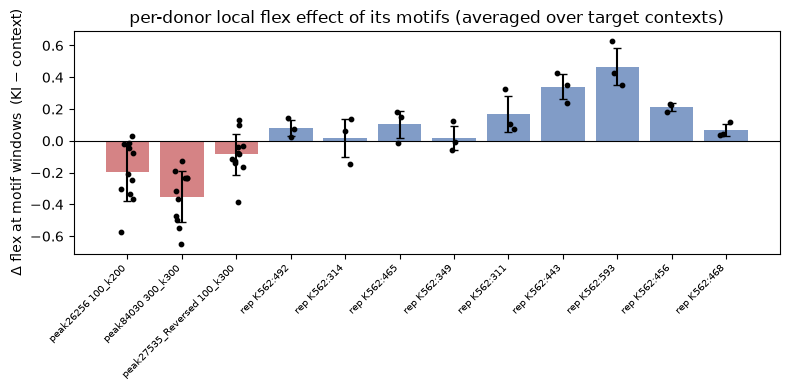

In [84]:
# per-donor local flex effect of its motifs: Δflex = (KI chimera − same neutralized context) averaged over the
# donor's motif windows, then over every context it was dropped into. bar per donor (red=high, blue=low).
rng = np.random.default_rng(0)
don, tgt = Z["chimera_donor"], Z["chimera_target"]
prof_ki = np.stack([flex_model.profile_matrix(list(row)).mean(0) for row in Z["chimera"]])                       # (n_pairs,181)
prof_ctx = {i: flex_model.profile_matrix(list(row)).mean(0) for row, i in zip(Z["motifko"], Z["motifko_idx"].tolist())}
win_center = np.arange(prof_ki.shape[1]) + 50 // 2

donors = sorted(set(don.tolist()))
eff = {}
for d in donors:
    mwin = np.zeros(len(win_center), bool)                                  # windows centered in the donor's motifs
    for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == d], Z["mspan_end"][Z["mspan_seq"] == d]):
        mwin |= (win_center >= s) & (win_center < e)
    eff[d] = np.array([(prof_ki[k] - prof_ctx[int(tgt[k])])[mwin].mean() for k in np.where(don == d)[0]])

fig, ax = plt.subplots(figsize=(8, 4))
for x, d in enumerate(donors):
    ax.bar(x, eff[d].mean(), yerr=eff[d].std(), color="#c44e52" if d in hi else "#4c72b0", alpha=0.7, capsize=3)
    ax.scatter(x + rng.uniform(-0.12, 0.12, len(eff[d])), eff[d], s=10, color="k", zorder=3)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(donors))); ax.set_xticklabels([names[d] for d in donors], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Δ flex at motif windows  (KI − context)")
ax.set_title("per-donor local flex effect of its motifs (averaged over target contexts)")
plt.tight_layout()

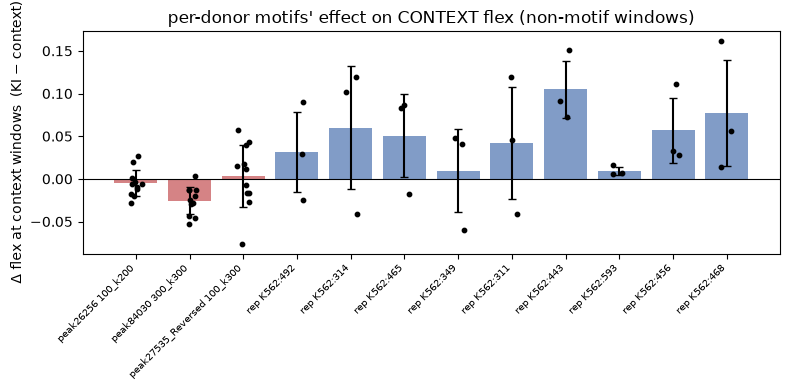

In [85]:
# same, but the donor motifs' effect on CONTEXT flex: Δflex = (KI chimera − same context) averaged over the
# NON-motif (context) windows, then over every target context. bar per donor (red=high, blue=low).
eff_ctx = {}
for d in donors:
    mwin = np.zeros(len(win_center), bool)
    for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == d], Z["mspan_end"][Z["mspan_seq"] == d]):
        mwin |= (win_center >= s) & (win_center < e)
    ctxwin = ~mwin                                                          # windows outside the donor's motifs
    eff_ctx[d] = np.array([(prof_ki[k] - prof_ctx[int(tgt[k])])[ctxwin].mean() for k in np.where(don == d)[0]])

fig, ax = plt.subplots(figsize=(8, 4))
for x, d in enumerate(donors):
    ax.bar(x, eff_ctx[d].mean(), yerr=eff_ctx[d].std(), color="#c44e52" if d in hi else "#4c72b0", alpha=0.7, capsize=3)
    ax.scatter(x + rng.uniform(-0.12, 0.12, len(eff_ctx[d])), eff_ctx[d], s=10, color="k", zorder=3)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(donors))); ax.set_xticklabels([names[d] for d in donors], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Δ flex at context windows  (KI − context)")
ax.set_title("per-donor motifs' effect on CONTEXT flex (non-motif windows)")
plt.tight_layout()

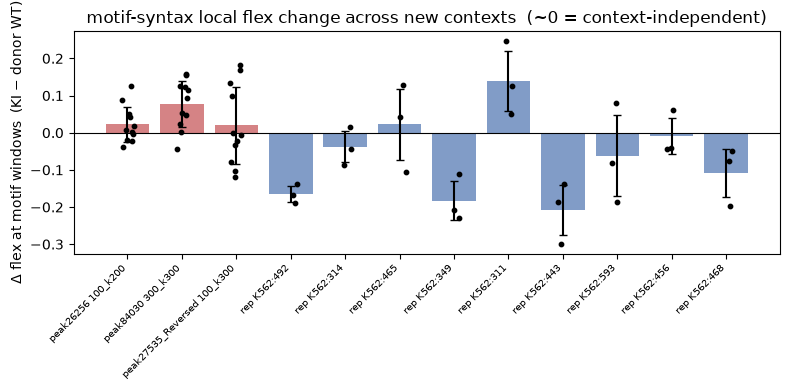

In [88]:
# change in local flex when a donor's motif syntax is placed into a NEW context:
# Δ = (KI chimera − donor WT) at the donor's motif windows, averaged over every target context.
# ~0 => the motifs alone set their local flex (context-independent); large => context reshapes motif flex.
prof_wt_all = flex_model.profile_matrix(list(wt))                          # (13,181) by seq id
eff_move = {}
for d in donors:
    mwin = np.zeros(len(win_center), bool)
    for s, e in zip(Z["mspan_start"][Z["mspan_seq"] == d], Z["mspan_end"][Z["mspan_seq"] == d]):
        mwin |= (win_center >= s) & (win_center < e)
    wt_m = prof_wt_all[d][mwin].mean()
    eff_move[d] = np.array([prof_ki[k][mwin].mean() - wt_m for k in np.where(don == d)[0]])

fig, ax = plt.subplots(figsize=(8, 4))
for x, d in enumerate(donors):
    ax.bar(x, eff_move[d].mean(), yerr=eff_move[d].std(), color="#c44e52" if d in hi else "#4c72b0", alpha=0.7, capsize=3)
    ax.scatter(x + rng.uniform(-0.12, 0.12, len(eff_move[d])), eff_move[d], s=10, color="k", zorder=3)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(donors))); ax.set_xticklabels([names[d] for d in donors], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Δ flex at motif windows  (KI − donor WT)")
ax.set_title("motif-syntax local flex change across new contexts  (~0 = context-independent)")
plt.tight_layout()